# Day-Ahead Energy Consumption Forecasting Pipeline

End-to-end pipeline that trains a LightGBM forecaster on Aneo consumption data and produces day-ahead predictions for the 14-day test window across the five Norwegian price areas.

**Pipeline:**

1. Load and preprocess data
2. Per-location z-score standardization (expanding, delay-aware)
3. Feature engineering (calendar, daylight, temperature, lagged consumption)
4. Build expanding-window day-ahead splits
5. Tune LightGBM hyperparameters with Optuna
6. Select model vs. naive baseline per location on the last tune fold
7. Walk-forward backtest on the test window


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import lightgbm as lgb
import optuna

In [2]:
DELAY_DAYS = 5
TEST_DAYS = 14
VAL_DAYS = 14
TUNE_FOLDS = 4
TUNE_FOLD_DAYS = 14

In [3]:
df = pd.read_csv('consumption_temp.csv')
df.head()

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


## 2. Preprocessing

Filter to the five Norwegian price areas, parse timestamps, and sort.

In [4]:
def preprocess_data(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["time"])
    df["location"] = df["location"].astype(str).str.strip().str.lower()

    norwegian = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]
    df = df[df["location"].isin(norwegian)].copy()

    df = df.set_index("datetime").sort_index()
    df = df.drop(columns=["time"])
    return df


norw_df = preprocess_data(df)
norw_df.head()

,location,consumption,temperature
datetime,,,
2022-04-07 21:00:00,bergen,1.113325,-0.3
2022-04-07 21:00:00,oslo,4.092830,1.0
2022-04-07 21:00:00,stavanger,2.057858,1.3
2022-04-07 21:00:00,tromsø,1.246582,-3.9
2022-04-07 21:00:00,trondheim,1.970098,-2.8


## 3. Target Standardization

Per-location z-score normalization using an expanding window shifted by the 5-day delay, so normalization statistics at any time only use values that would have been available in production.

In [5]:
def add_location_standardization(data, target_col="consumption", delay_days=5):
    delay_h = delay_days * 24
    out = data.copy()

    grp = out.groupby("location")[target_col]
    shifted = grp.shift(delay_h)

    out["_loc_mean"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).mean()
    )
    out["_loc_std"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).std()
    )
    out["consumption_z"] = (out[target_col] - out["_loc_mean"]) / out["_loc_std"]
    return out


def invert_standardization(predictions_df, data):
    out = predictions_df.copy()
    stats = data[["location", "_loc_mean", "_loc_std"]].copy()
    stats["timestamp"] = stats.index
    out = out.merge(
        stats[["timestamp", "location", "_loc_mean", "_loc_std"]],
        on=["timestamp", "location"], how="left",
    )
    out["y_pred_mw"] = out["y_pred"] * out["_loc_std"] + out["_loc_mean"]
    out["y_true_mw"] = out["y_true"] * out["_loc_std"] + out["_loc_mean"]
    return out

## 4. Feature Engineering

Three information sources available at forecast time: calendar/daylight, temperature forecasts (available for the target day), and lagged consumption (respecting the 5-day delay).

In [6]:
def daylight_hours(latitude, day_of_year):
    lat_rad = np.radians(latitude)
    declination = 23.45 * np.sin(np.radians(360 / 365 * (day_of_year - 81)))
    decl_rad = np.radians(declination)
    cos_ha = np.clip(-np.tan(lat_rad) * np.tan(decl_rad), -1, 1)
    return 2 * np.degrees(np.arccos(cos_ha)) / 15


def add_features(df, delay_days=5):
    out = df.copy()
    delay_h = delay_days * 24

    # --- Location ---
    out["location"] = out["location"].astype("category")
    lat_map = {
        "bergen": 60.39, "oslo": 59.91, "stavanger": 58.97,
        "tromsø": 69.65, "trondheim": 63.43,
    }
    out["latitude"] = out["location"].map(lat_map)

    # --- Calendar ---
    hour = out.index.hour
    dow = out.index.dayofweek
    out["hour"] = hour
    out["dow"] = dow
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["day_of_year"] = out.index.dayofyear

    # --- Daylight ---
    out["daylight_hours"] = daylight_hours(
        out["latitude"].astype(float).values, out["day_of_year"].values
    )
    out["daylight_change_7d"] = (
        out["daylight_hours"] - out.groupby("location")["daylight_hours"].shift(168)
    )

    # --- Temperature ---
    out["heating_degree_18"] = np.maximum(0.0, 18.0 - out["temperature"])

    shifted_temp = out.groupby("location")["temperature"].shift(1)
    out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(24, min_periods=24).mean()
    )
    out["temp_roll_mean_168"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["temp_delta_24h"] = out["temperature"] - out.groupby("location")["temperature"].shift(24)

    out["_date"] = out.index.date
    out["temp_day_mean"] = out.groupby(["location", "_date"])["temperature"].transform("mean")
    out.drop(columns=["_date"], inplace=True)

    out["temp_at_time_1d"] = out.groupby("location")["temperature"].shift(24)
    out["avg_temp_at_time_3d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 4)
    ) / 3.0
    out["avg_temp_at_time_7d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 8)
    ) / 7.0
    out["avg_temp_at_time_14d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 15)
    ) / 14.0

    out["temp_gap_delta"] = (
        out["temperature"] - out.groupby("location")["temperature"].shift(delay_h)
    )

    # --- Consumption lags (z-scored, respecting 5-day delay) ---
    grp_z = out.groupby("location")["consumption_z"]

    out["lag_120"] = grp_z.shift(120)
    out["lag_168"] = grp_z.shift(168)
    out["lag_336"] = grp_z.shift(336)
    out["lag_168_diff"] = out["lag_168"] - out["lag_336"]
    out["lag_120_168_diff"] = out["lag_120"] - out["lag_168"]

    out["avg_cons_at_time_5_7d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 8)
    ) / 3.0
    out["avg_cons_at_time_5_11d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 12)
    ) / 7.0

    avail_z = grp_z.shift(delay_h)
    out["avail_roll_mean_168"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["avail_roll_mean_336"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(336, min_periods=336).mean()
    )

    # --- Recent drift ---
    week_change = (
        out.groupby("location")["consumption_z"].shift(delay_h)
        - out.groupby("location")["consumption_z"].shift(delay_h + 168)
    )
    out["recent_drift_mean_7d"] = week_change.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=24).mean()
    )

    return out


cons_z = add_location_standardization(norw_df)
data = add_features(cons_z).dropna()
data.head()

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/3470440509.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["daylight_hours"] - out.groupby("location")["daylight_hours"].shift(168)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/3470440509.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted_temp = out.groupby("location")["temperature"].shift(1)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/3470440509.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fal

,location,consumption,temperature,_loc_mean,_loc_std,consumption_z,latitude,hour,dow,hour_sin,...,lag_120,lag_168,lag_336,lag_168_diff,lag_120_168_diff,avg_cons_at_time_5_7d,avg_cons_at_time_5_11d,avail_roll_mean_168,avail_roll_mean_336,recent_drift_mean_7d
datetime,,,,,,,,,,,,,,,,,,,,,
2022-05-08 19:00:00,bergen,0.908972,8.0,0.820844,0.158947,0.554449,60.39,19,6,-0.965926,...,0.314885,0.097733,-1.128623,1.226355,0.217153,0.258935,0.157062,-0.604792,-1.601372,1.993161
2022-05-08 19:00:00,oslo,2.831582,11.8,2.809865,0.477492,0.045481,59.91,19,6,-0.965926,...,0.313790,0.286172,-0.258996,0.545168,0.027618,0.248852,0.246411,-0.510144,-1.301784,1.583280
2022-05-08 19:00:00,stavanger,1.506519,7.7,1.452001,0.251656,0.216636,58.97,19,6,-0.965926,...,0.215892,0.025137,-0.154164,0.179301,0.190755,0.133926,-0.004414,-0.820704,-1.701681,1.761953
2022-05-08 19:00:00,tromsø,1.248539,1.3,1.042705,0.121503,1.694065,69.65,19,6,-0.965926,...,2.311001,2.192887,0.246785,1.946102,0.118113,2.374561,2.267344,1.234552,0.004620,2.459864
2022-05-08 19:00:00,trondheim,1.724760,7.4,1.480718,0.233329,1.045915,63.43,19,6,-0.965926,...,1.640571,1.020611,-0.501623,1.522234,0.619960,1.409282,1.354006,0.324936,-0.615372,1.880615


## 5. Train/Test Splits

Expanding-window day-ahead splits respecting the 5-day delay. Tune splits include a 14-day validation set for early stopping; test splits use all available data for training with frozen hyperparameters.

In [7]:
@dataclass
class ForecastSplit:
    forecast_date: pd.Timestamp
    avail_cutoff: pd.Timestamp
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series


def build_day_ahead_splits(
    data, forecast_days, target_col="consumption_z",
    val_days=14, delay_days=5, include_val=True,
):
    exclude = {target_col, "consumption", "_loc_mean", "_loc_std"}
    feature_cols = [c for c in data.columns if c not in exclude]
    splits = []

    for D in forecast_days:
        D = D.normalize()
        test_data = data[(data.index >= D) & (data.index < D + pd.Timedelta(days=1))]
        if test_data.empty:
            continue

        avail_day = (D - pd.Timedelta(days=delay_days)).normalize()
        avail_cutoff = avail_day + pd.Timedelta(hours=23)
        available = data[data.index <= avail_cutoff]

        if include_val:
            val_start = (avail_day - pd.Timedelta(days=val_days - 1)).normalize()
            val_data = available[available.index >= val_start]
            train_data = available[available.index < val_start]
            if train_data.empty or val_data.empty:
                continue
        else:
            train_data = available
            val_data = available.iloc[:0]
            if train_data.empty:
                continue

        splits.append(ForecastSplit(
            forecast_date=D, avail_cutoff=avail_cutoff,
            X_train=train_data[feature_cols], y_train=train_data[target_col],
            X_val=val_data[feature_cols], y_val=val_data[target_col],
            X_test=test_data[feature_cols], y_test=test_data[target_col],
        ))
    return splits


def build_multi_fold_tune_splits(
    data, test_start, n_folds=4, fold_days=14, val_days=14, delay_days=5,
):
    data_start = data.index.min().normalize() + pd.Timedelta(days=60)
    data_end = test_start - pd.Timedelta(days=1)
    spacing = (data_end - data_start).days // (n_folds + 1)

    all_splits, fold_info = [], []
    for fold in range(n_folds):
        fold_end = data_start + pd.Timedelta(days=spacing * (fold + 1))
        fold_start = fold_end - pd.Timedelta(days=fold_days - 1)
        fold_range = pd.date_range(fold_start, fold_end, freq="D")

        fold_splits = build_day_ahead_splits(
            data, fold_range, val_days=val_days,
            delay_days=delay_days, include_val=True,
        )
        all_splits.extend(fold_splits)
        if fold_splits:
            fold_info.append((
                fold_splits[0].forecast_date.date(),
                fold_splits[-1].forecast_date.date(),
                len(fold_splits),
            ))
    return all_splits, fold_info

In [8]:
target_col = "consumption_z"
last_day = data.index.max().normalize()

test_end = last_day
test_start = test_end - pd.Timedelta(days=TEST_DAYS - 1)
test_day_range = pd.date_range(test_start, test_end, freq="D")

tune_splits, fold_info = build_multi_fold_tune_splits(
    data, test_start, n_folds=TUNE_FOLDS, fold_days=TUNE_FOLD_DAYS,
    val_days=VAL_DAYS, delay_days=DELAY_DAYS,
)

test_splits = build_day_ahead_splits(
    data, test_day_range, delay_days=DELAY_DAYS, include_val=False,
)

# Leakage assertions
for label, splits, has_val in [("TUNE", tune_splits, True), ("TEST", test_splits, False)]:
    for s in splits:
        D = s.forecast_date
        gap_start = (D - pd.Timedelta(days=DELAY_DAYS - 1)).normalize()
        assert s.X_train.index.max() < gap_start
        assert s.X_train.index.max() <= s.avail_cutoff
        if has_val:
            assert s.X_val.index.max() < gap_start
            assert s.X_val.index.max() <= s.avail_cutoff
            assert s.X_train.index.max() < s.X_val.index.min()

print(f"TUNE: {len(tune_splits)} splits across {len(fold_info)} folds:")
for start, end, n in fold_info:
    print(f"  Fold {start} → {end} ({n} days)")

s0, sN = test_splits[0], test_splits[-1]
print(f"\nTEST window: {s0.forecast_date.date()} -> {sN.forecast_date.date()} ({len(test_splits)} days)")
print(f"  first: avail={s0.avail_cutoff.date()}, train={len(s0.y_train):,} rows")
print(f"  last:  avail={sN.avail_cutoff.date()}, train={len(sN.y_train):,} rows")

TUNE: 56 splits across 4 folds:
  Fold 2022-08-14 → 2022-08-27 (14 days)
  Fold 2022-10-04 → 2022-10-17 (14 days)
  Fold 2022-11-24 → 2022-12-07 (14 days)
  Fold 2023-01-14 → 2023-01-27 (14 days)

TEST window: 2023-03-20 -> 2023-04-02 (14 days)
  first: avail=2023-03-15, train=37,345 rows
  last:  avail=2023-03-28, train=38,905 rows


## 6. Model Setup

LightGBM with L1 objective and linear trees. Location-balanced sample weights (sqrt-inverse of mean consumption) prevent the model from disproportionately optimizing for high-consumption locations like Oslo.

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

target_col = "consumption_z"
exclude = {"consumption", "consumption_z", "_loc_mean", "_loc_std"}
feature_cols = [c for c in data.columns if c not in exclude]
cat_features = ["location"]


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0


def location_balance_weights(X_train):
    loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
    inv_means = 1.0 / np.sqrt(loc_means)
    inv_means = inv_means / inv_means.mean()
    return X_train["location"].map(inv_means).astype(float).values


def make_model(params):
    base = dict(
        objective="regression_l1", boosting_type="gbdt",
        n_estimators=2000, bagging_freq=1, linear_tree=True,
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    base.update(params)
    return lgb.LGBMRegressor(**base)

## 7. Hyperparameter Tuning

Optuna tunes on the late tune folds (which have sufficient training data for stable early stopping). The 75th percentile of early-stopping iterations is used as the fixed `n_estimators` for test evaluation.

In [10]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 150),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "path_smooth": trial.suggest_float("path_smooth", 0.0, 10.0),
        "extra_trees": trial.suggest_categorical("extra_trees", [True, False]),
    }

    late_folds = tune_splits[len(tune_splits) // 2:]
    tune_subset = late_folds[::3]
    scores, best_iters = [], []

    for step, split in enumerate(tune_subset):
        model = make_model({**params, "n_estimators": 1000})
        weights = location_balance_weights(split.X_train)
        model.fit(
            split.X_train, split.y_train, sample_weight=weights,
            eval_set=[(split.X_val, split.y_val)], eval_metric="l1",
            callbacks=[lgb.early_stopping(50, verbose=False)],
            categorical_feature=cat_features,
        )
        best_iters.append(model.best_iteration_)
        scores.append(mae(split.y_val.values, model.predict(split.X_val)))

        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("n_estimators", int(np.percentile(best_iters, 75)))
    return float(np.mean(scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(objective, n_trials=25, show_progress_bar=True)

best_params = study.best_trial.params
best_n_estimators = study.best_trial.user_attrs["n_estimators"]

print(f"\nBest tune MAE: {study.best_value:.4f}")
print(f"Best params:   {best_params}")
print(f"Best n_estimators (75th pct early stop): {best_n_estimators}")

  0%|          | 0/25 [00:00<?, ?it/s]

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P


Best tune MAE: 0.4105
Best params:   {'learning_rate': 0.032491530533916, 'num_leaves': 7, 'max_depth': 5, 'min_child_samples': 70, 'reg_lambda': 1.1516719627385013, 'reg_alpha': 0.17714269871565663, 'subsample': 0.8070733224593357, 'colsample_bytree': 0.6117451704166061, 'path_smooth': 2.382567484038675, 'extra_trees': True}
Best n_estimators (75th pct early stop): 267


## 8. Per-Location Model Selection

For each location, the model is compared against the naive baseline (average of lag 120h + 168h) on the last tune fold. Locations where the baseline wins use baseline predictions at test time. Decision uses three-way data separation (train → val → test) with no test data leakage.

In [11]:
lookup = data.reset_index().set_index(["datetime", "location"])


def baseline_avg_at_timestamps(timestamps, locations):
    preds = []
    for ts, loc in zip(timestamps, locations):
        try:
            lag5 = lookup.loc[(ts - pd.Timedelta(hours=120), loc), "consumption"]
            lag7 = lookup.loc[(ts - pd.Timedelta(hours=168), loc), "consumption"]
            preds.append((lag5 + lag7) / 2.0)
        except KeyError:
            preds.append(np.nan)
    return np.array(preds)


# Evaluate on last tune fold's forecast days
last_fold_start = tune_splits[-1].forecast_date - pd.Timedelta(days=13)
last_fold_splits = [s for s in tune_splits if s.forecast_date >= last_fold_start]

tune_eval_rows = []
for split in last_fold_splits:
    model = make_model({**best_params, "n_estimators": 1000})
    weights = location_balance_weights(split.X_train)
    model.fit(
        split.X_train, split.y_train, sample_weight=weights,
        eval_set=[(split.X_val, split.y_val)], eval_metric="l1",
        callbacks=[lgb.early_stopping(50, verbose=False)],
        categorical_feature=cat_features,
    )

    y_pred_z = model.predict(split.X_test)
    timestamps = split.X_test.index
    locations = split.X_test["location"].values

    for idx, (ts, loc) in enumerate(zip(timestamps, locations)):
        row_data = data.loc[ts]
        if isinstance(row_data, pd.DataFrame):
            row_data = row_data[row_data["location"] == loc].iloc[0]
        loc_mean, loc_std = row_data["_loc_mean"], row_data["_loc_std"]
        tune_eval_rows.append({
            "timestamp": ts, "location": loc,
            "y_true_mw": split.y_test.iloc[idx] * loc_std + loc_mean,
            "y_pred_model_mw": y_pred_z[idx] * loc_std + loc_mean,
        })

tune_eval = pd.DataFrame(tune_eval_rows)
tune_eval["y_pred_baseline_mw"] = baseline_avg_at_timestamps(
    tune_eval["timestamp"].values, tune_eval["location"].values,
)
tune_eval = tune_eval.dropna(subset=["y_pred_baseline_mw"])

use_model = {}
print(f"Per-location model selection (last tune fold: "
      f"{last_fold_splits[0].forecast_date.date()} -> {last_fold_splits[-1].forecast_date.date()}):\n")

for loc in sorted(tune_eval["location"].unique()):
    loc_data = tune_eval[tune_eval["location"] == loc]
    m_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_model_mw"])
    b_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_baseline_mw"])
    use_model[loc] = m_smape <= b_smape
    print(f"  {loc.capitalize():12s}: model={m_smape:.2f}%, baseline={b_smape:.2f}% → "
          f"{'MODEL' if use_model[loc] else 'BASELINE'}")

print(f"\nUsing model:    {[l for l, v in use_model.items() if v]}")
print(f"Using baseline: {[l for l, v in use_model.items() if not v]}")

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

Per-location model selection (last tune fold: 2023-01-14 -> 2023-01-27):

  Bergen      : model=9.18%, baseline=13.09% → MODEL
  Oslo        : model=9.23%, baseline=11.88% → MODEL
  Stavanger   : model=8.32%, baseline=12.37% → MODEL
  Tromsø      : model=10.64%, baseline=5.32% → BASELINE
  Trondheim   : model=9.94%, baseline=10.47% → MODEL

Using model:    ['bergen', 'oslo', 'stavanger', 'trondheim']
Using baseline: ['tromsø']


## 9. Test Backtest

14-day walk-forward evaluation. For each test day, the model is retrained on all available data with the frozen hyperparameters. Locations flagged for baseline fallback receive lag-average predictions converted to z-score for uniform inversion.

In [12]:
pred_rows, daily_rows = [], []

print("Running TEST backtest (model + baseline fallback)\n")

for i, split in enumerate(test_splits, start=1):
    model = make_model({**best_params, "n_estimators": best_n_estimators})
    weights = location_balance_weights(split.X_train)
    model.fit(split.X_train, split.y_train,
              sample_weight=weights, categorical_feature=cat_features)

    y_pred_z = model.predict(split.X_test)
    y_true = split.y_test.values
    locations = split.X_test["location"].values
    timestamps = split.X_test.index

    y_pred_final_z = y_pred_z.copy()
    baseline_preds = baseline_avg_at_timestamps(timestamps, locations)

    for idx, loc in enumerate(locations):
        if not use_model[loc] and not np.isnan(baseline_preds[idx]):
            row_data = data.loc[timestamps[idx]]
            if isinstance(row_data, pd.DataFrame):
                row_data = row_data[row_data["location"] == loc].iloc[0]
            y_pred_final_z[idx] = (baseline_preds[idx] - row_data["_loc_mean"]) / row_data["_loc_std"]

    daily_rows.append({
        "forecast_date": split.forecast_date,
        "MAE": mae(y_true, y_pred_final_z),
        "RMSE": rmse(y_true, y_pred_final_z),
        "SMAPE_%": smape(y_true, y_pred_final_z),
    })

    pred_rows.append(pd.DataFrame({
        "forecast_date": split.forecast_date,
        "timestamp": timestamps,
        "location": locations,
        "y_true": y_true,
        "y_pred": y_pred_final_z,
    }))

    print(f"  Day {i:>2}/{len(test_splits)}  {split.forecast_date.date()}  "
          f"train={len(split.y_train):,}  "
          f"MAE={mae(y_true, y_pred_final_z):.4f}  RMSE={rmse(y_true, y_pred_final_z):.4f}")

predictions = pd.concat(pred_rows, ignore_index=True)
predictions = invert_standardization(predictions, data)

daily_metrics = pd.DataFrame([{
    "forecast_date": D,
    "MAE": mae(grp["y_true_mw"], grp["y_pred_mw"]),
    "RMSE": rmse(grp["y_true_mw"], grp["y_pred_mw"]),
    "SMAPE_%": smape(grp["y_true_mw"], grp["y_pred_mw"]),
} for D, grp in predictions.groupby("forecast_date")])

print(f"\n{'='*50}")
print(f"Overall MAE:   {daily_metrics['MAE'].mean():.4f} MW")
print(f"Overall RMSE:  {daily_metrics['RMSE'].mean():.4f} MW")
print(f"Overall SMAPE: {daily_metrics['SMAPE_%'].mean():.2f}%")

Running TEST backtest (model + baseline fallback)



/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day  1/14  2023-03-20  train=37,345  MAE=0.1835  RMSE=0.2339


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day  2/14  2023-03-21  train=37,465  MAE=0.1516  RMSE=0.1832


...

  Day 12/14  2023-03-31  train=38,665  MAE=0.1721  RMSE=0.2098


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day 13/14  2023-04-01  train=38,785  MAE=0.1316  RMSE=0.1549


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_55429/2041920353.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_means = data.loc[X_train.index].groupby("location")["consumption"].mean()


  Day 14/14  2023-04-02  train=38,905  MAE=0.1431  RMSE=0.1748

Overall MAE:   0.2651 MW
Overall RMSE:  0.3731 MW
Overall SMAPE: 5.64%


## 10. Results

In [13]:
print("Metrics by location:")
for loc in sorted(predictions["location"].unique()):
    loc_data = predictions[predictions["location"] == loc]
    print(f"  {loc.capitalize():12s}: MAE={mae(loc_data['y_true_mw'], loc_data['y_pred_mw']):.4f} MW, "
          f"RMSE={rmse(loc_data['y_true_mw'], loc_data['y_pred_mw']):.4f} MW, "
          f"SMAPE={smape(loc_data['y_true_mw'], loc_data['y_pred_mw']):.2f}%")

Metrics by location:
  Bergen      : MAE=0.1569 MW, RMSE=0.1899 MW, SMAPE=5.51%
  Oslo        : MAE=0.5153 MW, RMSE=0.6449 MW, SMAPE=4.72%
  Stavanger   : MAE=0.3457 MW, RMSE=0.4469 MW, SMAPE=6.75%
  Tromsø      : MAE=0.0986 MW, RMSE=0.1204 MW, SMAPE=5.22%
  Trondheim   : MAE=0.2088 MW, RMSE=0.2487 MW, SMAPE=6.03%


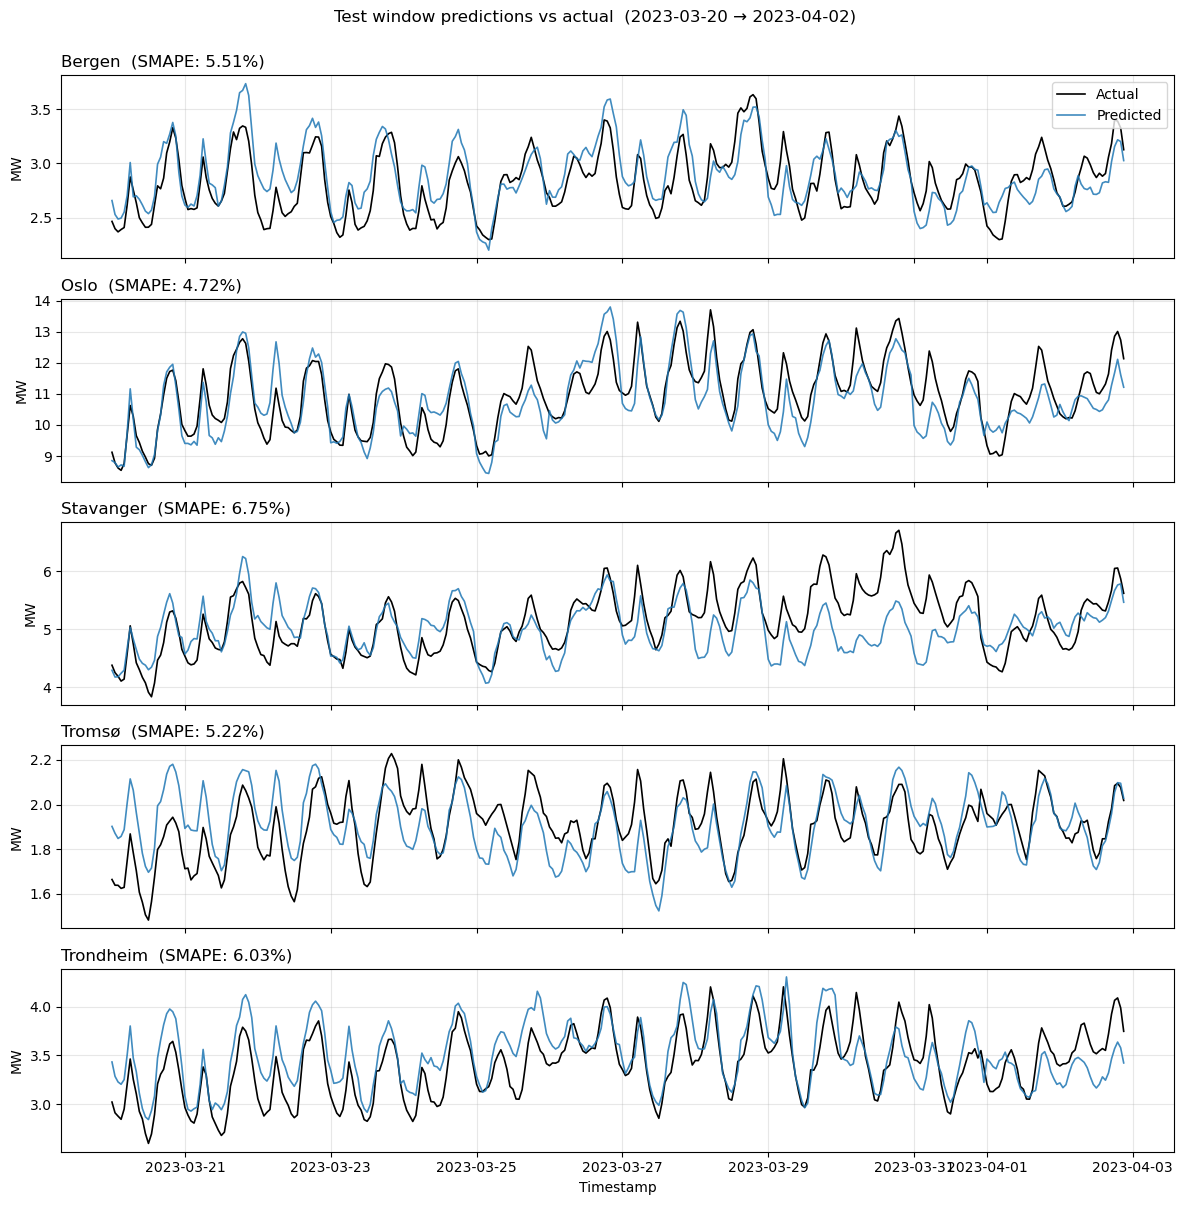

In [14]:
locations_sorted = sorted(predictions["location"].unique())
fig, axes = plt.subplots(len(locations_sorted), 1, figsize=(12, 2.4 * len(locations_sorted)),
                         sharex=True)

for ax, loc in zip(axes, locations_sorted):
    loc_data = predictions[predictions["location"] == loc].sort_values("timestamp")
    ax.plot(loc_data["timestamp"], loc_data["y_true_mw"],
            label="Actual", color="black", linewidth=1.2)
    ax.plot(loc_data["timestamp"], loc_data["y_pred_mw"],
            label="Predicted", color="tab:blue", linewidth=1.2, alpha=0.85)
    loc_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_mw"])
    ax.set_title(f"{loc.capitalize()}  (SMAPE: {loc_smape:.2f}%)", loc="left")
    ax.set_ylabel("MW")
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Timestamp")
fig.suptitle(f"Test window predictions vs actual  "
             f"({test_splits[0].forecast_date.date()} → {test_splits[-1].forecast_date.date()})",
             y=1.00)
plt.tight_layout()
plt.show()

In [15]:
predictions.to_csv("predictions.csv", index=False)
daily_metrics.to_csv("daily_metrics.csv", index=False)
print(f"Saved predictions ({len(predictions)} rows) and daily_metrics ({len(daily_metrics)} rows)")

Saved predictions (1670 rows) and daily_metrics (14 rows)
